# 	Case Study - Impact of COVID-19 on ABC Company’s Parcel Delivery Business.
### Group members:  Irorere Osaheni & Nadeem Baasil

## import the necessary libraries

In [114]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

### Read the csv file needed for analysis

In [115]:
covid_df = pd.read_csv('COVID_Parcel_Business.csv')

### Peform some analysis on the data.

In [116]:
covid_df.head()

,FakeCustomerID,THE_YEAR,THE_WEEK,VOLUME
0,718117,2021,1,8
1,718117,2020,7,257
2,718117,2019,39,141
3,718117,2018,1,14
4,718117,2021,2,192


In [117]:
covid_df.tail()

,FakeCustomerID,THE_YEAR,THE_WEEK,VOLUME
190714,228893,2019,13,30
190715,228893,2019,38,122
190716,228893,2019,48,99
190717,228893,2019,20,61
190718,228893,2019,19,56


In [10]:
covid_df.describe()

,FakeCustomerID,THE_YEAR,THE_WEEK,VOLUME
count,190719.000000,190719.000000,190719.000000,190719.000000
mean,541440.234963,2019.395220,25.676377,1174.911519
std,264861.365663,1.068845,14.722539,11586.730666
min,100771.000000,2018.000000,1.000000,1.000000
25%,308930.000000,2018.000000,13.000000,25.000000
50%,529707.000000,2019.000000,25.000000,58.000000
75%,778800.000000,2020.000000,38.000000,162.000000
max,999362.000000,2021.000000,53.000000,640590.000000


In [118]:
covid_df.isnull().sum()

FakeCustomerID    0
THE_YEAR          0
THE_WEEK          0
VOLUME            0
dtype: int64

### There were no null / empty values in the data set

In [12]:
covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190719 entries, 0 to 190718
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   FakeCustomerID  190719 non-null  int64
 1   THE_YEAR        190719 non-null  int64
 2   THE_WEEK        190719 non-null  int64
 3   VOLUME          190719 non-null  int64
dtypes: int64(4)
memory usage: 5.8 MB


In [15]:
covid_df.columns

Index(['FakeCustomerID', 'THE_YEAR', 'THE_WEEK', 'VOLUME'], dtype='object')

In [17]:
covid_df.groupby('THE_WEEK')['THE_WEEK'].count()

THE_WEEK
1     2886
2     3873
3     3886
4     3890
5     3887
6     3897
7     3887
8     3898
9     3913
10    3905
11    3899
12    3906
13    3846
14    3819
15    3840
16    3855
17    3860
18    3874
19    3878
20    3884
21    3873
22    3889
23    3908
24    3906
25    3907
26    3875
27    3831
28    3861
29    3855
30    3862
31    3818
32    3856
33    3879
34    3887
35    3895
36    3899
37    3891
38    3913
39    3908
40    2970
41    2973
42    2972
43    2968
44    2973
45    2966
46    2956
47    2957
48    2963
49    2974
50    2988
51    2967
52    2627
53    2169
Name: THE_WEEK, dtype: int64

### Let's find the weekly volume aggregate by the years.

In [18]:
w_vol = covid_df.groupby(['THE_YEAR', 'THE_WEEK'])['VOLUME'].sum().reset_index()

In [119]:
w_vol = w_vol.sort_values(['THE_YEAR', 'THE_WEEK'])
w_vol

,THE_YEAR,THE_WEEK,VOLUME
0,2018,1,817751
1,2018,2,925839
2,2018,3,854760
3,2018,4,800040
4,2018,5,812249
...,...,...,...
193,2021,35,1108902
194,2021,36,1102781
195,2021,37,1066316
196,2021,38,1026181


### From the data , we can detuct that  precovid weeks is from  Week 1 - Week 12
### And the Covid Observation is from 13 - 53 as thats around when servants were urged to go home.

## Let's plot a line graph for the weeks vs volume of parcel for the years(2019-2020)

In [120]:
w_pivot = w_vol.pivot(index='THE_WEEK', columns= 'THE_YEAR', values='VOLUME')

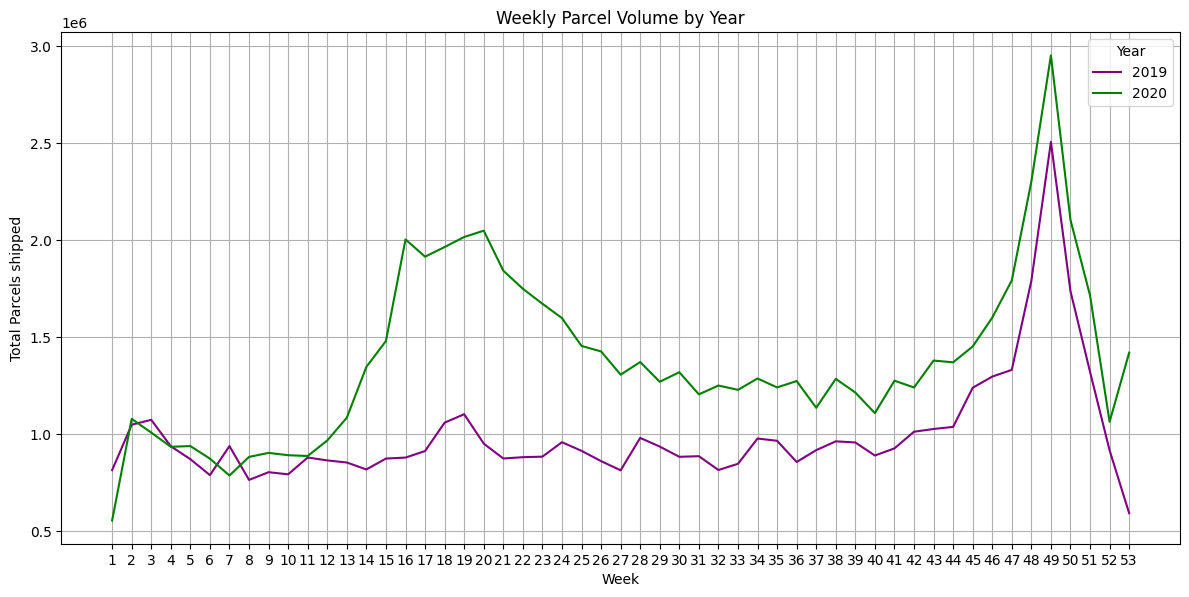

In [121]:
w_pivot[[2019, 2020]].plot(figsize=(12,6), color = ['purple', 'green'])
plt.xlabel("Week")
plt.ylabel("Total Parcels shipped")
plt.grid(True)
plt.tight_layout()
plt.legend(title='Year')
plt.title("Weekly Parcel Volume by Year")
plt.xticks(w_pivot.index)
plt.show()

### Now let's indicate where the volume were first impacted

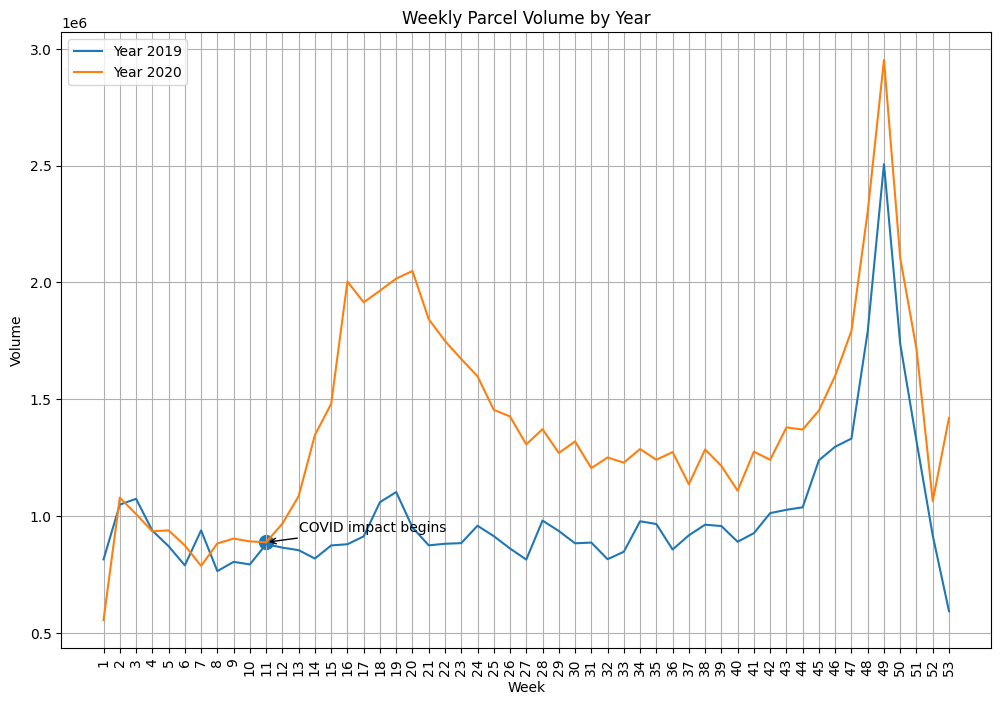

In [ ]:
plt.figure(figsize=(12,8))


for year in [2019, 2020]:
    temp = w_vol[w_vol['THE_YEAR'] == year]
    plt.plot(temp['THE_WEEK'], temp['VOLUME'], label=f"Year {year}")

covid_start_year = 2020
covid_start_week = 12  


point = w_vol[
    (w_vol['THE_YEAR'] == covid_start_year) &
    (w_vol['THE_WEEK'] == covid_start_week)
]


if not point.empty:
    x = point['THE_WEEK'].values[0]
    y = point['VOLUME'].values[0]

   
    plt.scatter(x, y, s=100)

    plt.annotate(
        "COVID impact begins",
        (x, y),
        xytext=(x+2, y*1.05),
        arrowprops=dict(arrowstyle="->")
    )
else:
    print("The week you selected does not exist in your dataset.")


plt.xlabel("Week")
plt.ylabel("Volume")
plt.title("Weekly Parcel Volume by Year")
plt.legend()
plt.grid(True)
plt.xticks(w_pivot.index, rotation = 90)
plt.show()


### from the graph above , you can see that teh week the impact started was on week 12.

## What events within the COVID timeline may have contributed to the change?

## The observed changes in customer volumes aligns with major COVID-19 events in Canada:

### Mid-March 2020 (Week 11–12): WHO declared COVID-19 a pandemic; federal and provincial governments began implementing lockdowns and travel restrictions.

### March–April 2020 (Week 12 - Week 13): Many businesses closed or shifted to remote work, reducing commercial shipping volumes temporarily.

### April–May 2020 (From Week 15): Surge in e-commerce and home deliveries began, partially offsetting declines in B2B shipments.

### These events together explain the sudden drop and subsequent changes in parcel volumes during the early weeks of the pandemic.”

## •	How did COVID-19 impact peak season in 2020?

### From the question, we can find out that the peak season fro 2020 was on November 2, now lets indicate on the line chart
### November 2 , 2020 falls in the 45th week.

#### reference: http://www.whatweekisit.org/

In [302]:
w_vol = w_vol.copy()

w_vol['CONT_WEEK'] = w_vol['THE_WEEK']
w_vol.loc[w_vol['THE_YEAR'] == 2020, 'CONT_WEEK'] += 52


In [303]:
peak_df = w_vol[
    ((w_vol['THE_YEAR'] == 2019) & (w_vol['THE_WEEK'] >= 45)) |
    ((w_vol['THE_YEAR'] == 2020))
]


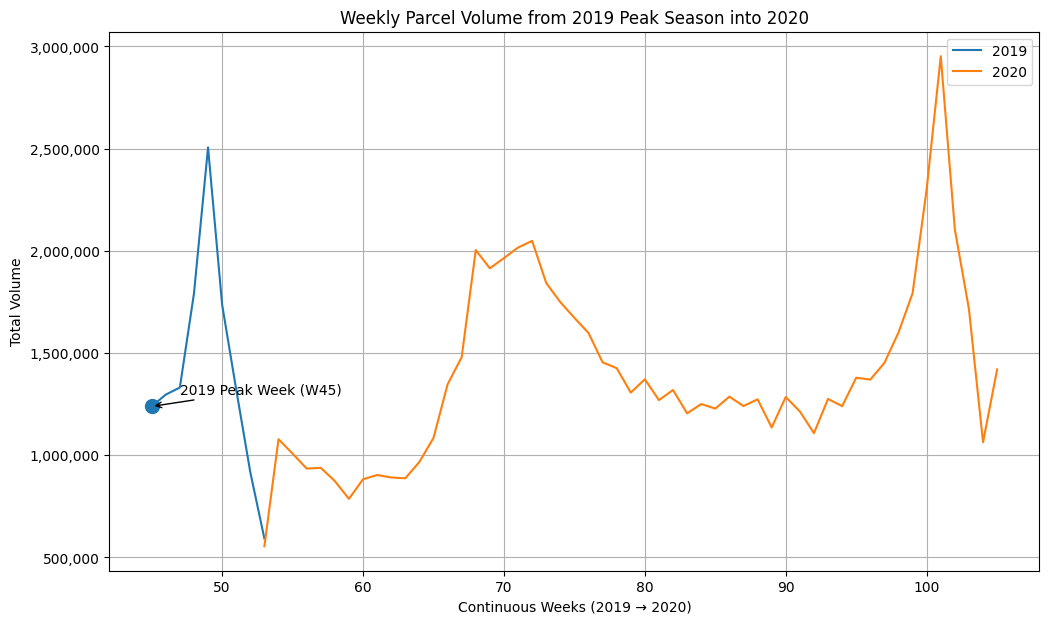

In [304]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,7))

for year in [2019, 2020]:
    temp = peak_df[peak_df['THE_YEAR'] == year]
    plt.plot(temp['CONT_WEEK'], temp['VOLUME'], label=str(year))

# Annotate peak week (2019, week 45)
peak_2019 = peak_df[
    (peak_df['THE_YEAR'] == 2019) &
    (peak_df['THE_WEEK'] == 45)
].iloc[0]

plt.scatter(peak_2019['CONT_WEEK'], peak_2019['VOLUME'], s=100)
plt.annotate(
    '2019 Peak Week (W45)',
    (peak_2019['CONT_WEEK'], peak_2019['VOLUME']),
    xytext=(peak_2019['CONT_WEEK']+2, peak_2019['VOLUME']*1.05),
    arrowprops=dict(arrowstyle='->')
)

plt.xlabel('Continuous Weeks (2019 → 2020)')
plt.ylabel('Total Volume')
plt.title('Weekly Parcel Volume from 2019 Peak Season into 2020')
plt.legend()
plt.grid(True)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{int(x):,}')
)

plt.show()


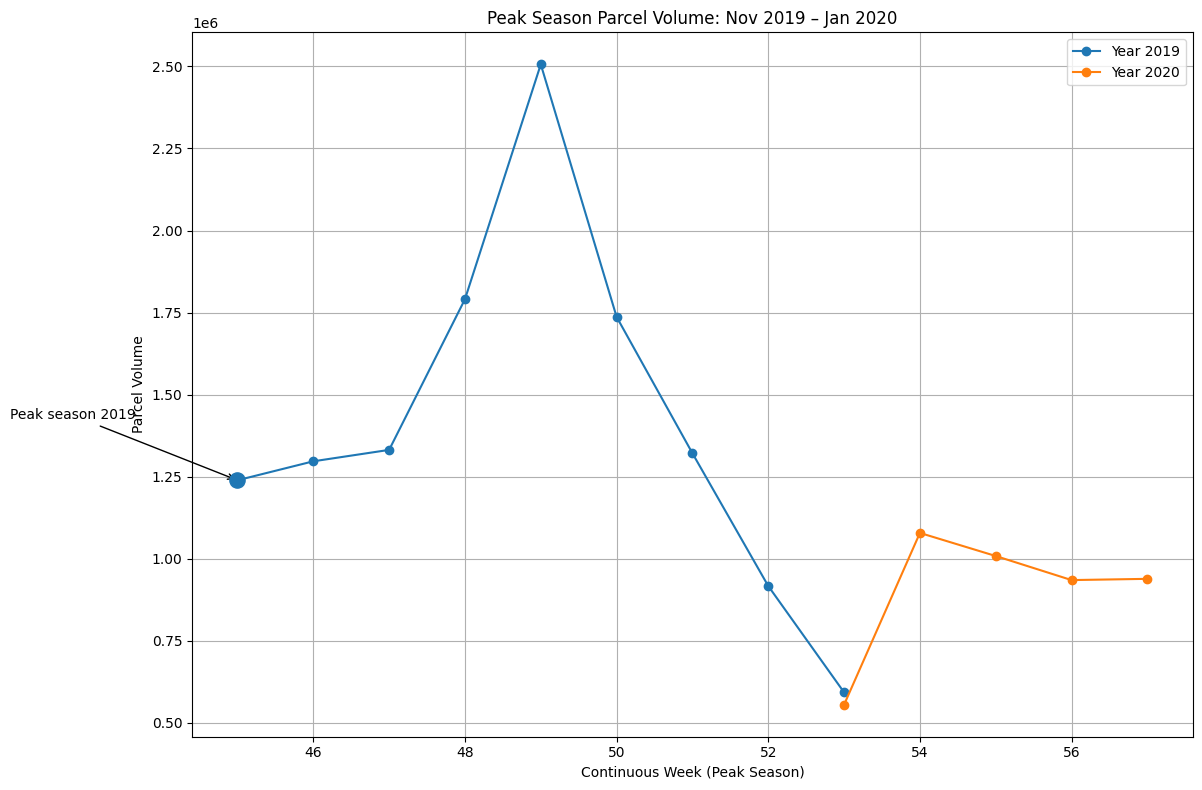

In [ ]:
plt.figure(figsize=(12,8))

for year in [2019, 2020]:
    temp = peak_df[peak_df['THE_YEAR'] == year]
    plt.plot(
        temp['CONT_WEEK'],
        temp['VOLUME'],
        marker='o',
        label=f"Year {year}"
    )

start_point = peak_df[
    (peak_df['THE_YEAR'] == 2019) &
    (peak_df['THE_WEEK'] == 45)
]

x = start_point['CONT_WEEK'].values[0]
y = start_point['VOLUME'].values[0]

plt.scatter(x, y, s=120, zorder=5)

plt.annotate(
    "Peak season 2019",
    xy=(x, y),
    xytext=(x-3, y*1.15),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.xlabel("Continuous Week (Peak Season)")
plt.ylabel("Parcel Volume")
plt.title("Peak Season Parcel Volume: Nov 2019 – Jan 2020")
plt.legend()
plt.grid(True)
# plt.xticks(w_pivot.index, rotation = 90)
plt.tight_layout()
plt.show()



In [283]:
weekly_customers = covid_df.groupby(['THE_YEAR', 'THE_WEEK'])['FakeCustomerID'].nunique().reset_index(name='NUM_CUSTOMERS')
weekly_customers.head()

,THE_YEAR,THE_WEEK,NUM_CUSTOMERS
0,2018,1,872
1,2018,2,908
2,2018,3,915
3,2018,4,914
4,2018,5,914


In [284]:
customers_2019 = weekly_customers[weekly_customers['THE_YEAR'] == 2019]
customers_2020 = weekly_customers[weekly_customers['THE_YEAR'] == 2020]

print("Weekly customers – 2019")
print(customers_2019)

print("\nWeekly customers – 2020")
print(customers_2020)


Weekly customers – 2019
     THE_YEAR  THE_WEEK  NUM_CUSTOMERS
53       2019         1            926
54       2019         2            987
55       2019         3            984
56       2019         4            994
57       2019         5            994
58       2019         6           1004
59       2019         7            999
60       2019         8           1001
61       2019         9           1005
62       2019        10           1004
63       2019        11           1004
64       2019        12           1005
65       2019        13           1001
66       2019        14           1008
67       2019        15           1009
68       2019        16           1009
69       2019        17           1012
70       2019        18           1017
71       2019        19           1009
72       2019        20           1009
73       2019        21           1006
74       2019        22           1010
75       2019        23           1015
76       2019        24           1007
7

In [299]:
weekly_volume_19_20 = (
    covid_df
    .groupby(['THE_WEEK', 'THE_YEAR'])['VOLUME']
    .sum()
    .unstack(fill_value=0)
    [[2019, 2020]]
)
weekly_volume_19_20


THE_YEAR,2019,2020
THE_WEEK,,
1,814361,554951
2,1048800,1078417
3,1073634,1008084
4,937502,934713
5,870849,938521
6,788670,873763
7,938386,786626
8,764078,882633
9,803745,903362


### Peak season in 2020 showed different behaviors compared to 2019. Weekly parcel volumes for 2019 and 2020 were aggregated using a pivot table to enable direct weekly comparisons.
### Although peak season normally brings a steady rise in parcel volume toward the end of the year, the 2020 peak was affected by COVID-19 in several ways:

### 1 Volumes started increasing earlier than usual, as more customers turned to online shopping.

### 2 The overall demand during peak was higher than in 2019, driven largely by e-commerce.

### 3 Some weeks showed unusual spikes or fluctuations, reflecting shifting consumer behavior and pandemic restrictions.

### 4 The peak season period lasted longer, because holiday shopping began earlier and continued past the usual peak window.

# Main Business question
## How did the COVID-19 pandemic impact ABC Company’s parcel business?
### From the data and analysis above, we have uncovered the following:

#### The COVID-19 pandemic caused a significant shift in ABC Company’s parcel volumes throughout 2020.

#### Early in the year (around Week 10–12), customer volumes were disrupted as lockdowns and restrictions began across Canada.

#### Some business customers reduced or paused shipping, especially those affected by closures or reduced operations.

#### At the same time, consumer e-commerce demand increased, leading to higher residential deliveries.

#### Overall volumes grew during the latter part of the year, especially during peak season, which started earlier and reached higher levels than in 2019.

#### The business experienced greater variability week-to-week, reflecting the changing conditions and responses to COVID-19 measures.

## The Impact of COVID on Customer Segments

###	How has COVID affected companies in the different customer groups (Enterprise, Large, etc.)?	
### First we would need to create a new column to group teh customers and calculate the total volume of each customer fro teh year

In [307]:
total_customers = (
    covid_df[covid_df['THE_YEAR'].isin([2019, 2020])]
    .groupby('THE_YEAR')['FakeCustomerID']
    .nunique()
)

print(total_customers)

THE_YEAR
2019    1061
2020    1046
Name: FakeCustomerID, dtype: int64


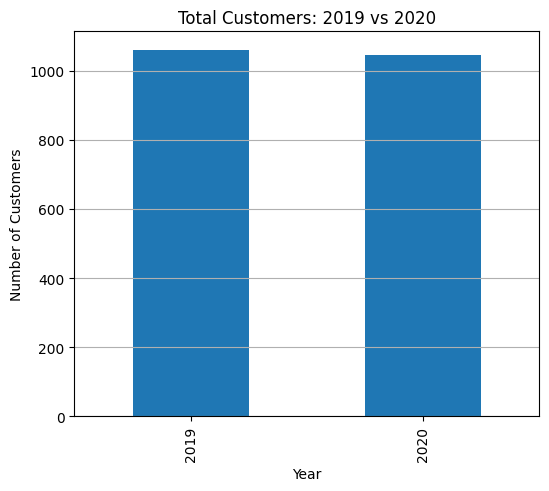

In [308]:
plt.figure(figsize=(6,5))

total_customers.plot(kind='bar')

plt.xlabel('Year')
plt.ylabel('Number of Customers')
plt.title('Total Customers: 2019 vs 2020')
plt.grid(axis='y')

plt.show()

### Weekly parcel volumes were plotted from the 2019 peak season (week 45) into 2020 using a continuous weekly index to illustrate how peak activity carried over across calendar years. Total customer counts were then compared between 2019 and 2020 to assess changes in customer participation.

In [206]:
covid_df.groupby('THE_YEAR')['VOLUME'].sum()

THE_YEAR
2018    49099478
2019    52823114
2020    73475690
2021    48679668
Name: VOLUME, dtype: int64

In [211]:
df_filter = covid_df[covid_df['THE_YEAR'].isin([2019, 2020])]


cust_year_vol = (df_filter.groupby(['FakeCustomerID', 'THE_YEAR'])['VOLUME'].sum().reset_index())



In [212]:
def group_assign(volume):
    if volume > 500000:
        return 'Enterprise'
    elif 200000 <= volume < 500000:
        return 'Large'
    elif 10000 <= volume < 200000:
        return 'Medium'
    elif 1000 <= volume < 10000:
        return 'Small'
    else:
        return 'Lesser than 1K'


In [213]:
cust_year_vol['CATEGORY'] = cust_year_vol['VOLUME'].apply(group_assign)

In [214]:
customer_year_summary = cust_year_vol.copy()
customer_year_summary


,FakeCustomerID,THE_YEAR,VOLUME,CATEGORY
0,100771,2019,1816,Small
1,100771,2020,1789,Small
2,102180,2019,5222,Small
3,102180,2020,4817,Small
4,102643,2019,2670,Small
...,...,...,...,...
2102,995173,2020,4920,Small
2103,999141,2019,3364,Small
2104,999141,2020,3619,Small
2105,999362,2019,3561,Small


In [215]:
updated_df = customer_year_summary.to_csv('UpdatedDF.csv')

In [195]:
updated_DF = pd.read_csv('UpdatedDF.csv')

### Let's find teh total number of customers in each of the customer group

In [272]:
customer_counts_year = (
    customer_year_summary
    .groupby(['CATEGORY', 'THE_YEAR'])['FakeCustomerID']
    .nunique()
    .reset_index(name='NUM_CUSTOMERS')
)

print(customer_counts_year)


         CATEGORY  THE_YEAR  NUM_CUSTOMERS
0      Enterprise      2019             12
1      Enterprise      2020             14
2           Large      2019             15
3           Large      2020             22
4  Lesser than 1K      2020             95
5          Medium      2019            174
6          Medium      2020            234
7           Small      2019            860
8           Small      2020            681


In [273]:
pivot_counts = customer_counts_year.pivot(
    index='CATEGORY',
    columns='THE_YEAR',
    values='NUM_CUSTOMERS'
).fillna(0)

print(pivot_counts)


THE_YEAR         2019   2020
CATEGORY                    
Enterprise       12.0   14.0
Large            15.0   22.0
Lesser than 1K    0.0   95.0
Medium          174.0  234.0
Small           860.0  681.0


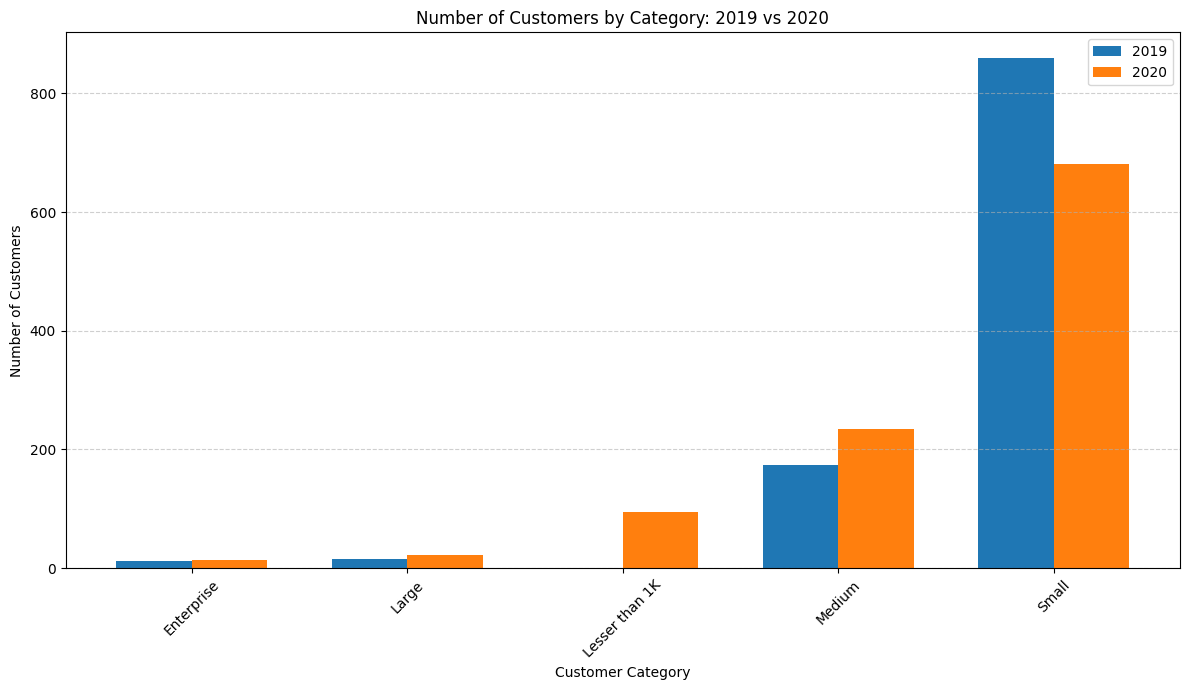

In [274]:
import matplotlib.pyplot as plt
import numpy as np

categories = pivot_counts.index
x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(12,7))

plt.bar(x - width/2, pivot_counts[2019], width, label='2019')
plt.bar(x + width/2, pivot_counts[2020], width, label='2020')

plt.xticks(x, categories, rotation=45)
plt.ylabel('Number of Customers')
plt.xlabel('Customer Category')
plt.title('Number of Customers by Category: 2019 vs 2020')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### While the number of Enterprise customers remains relatively small, their count increased in 2020. In contrast, the Small customer segment experienced a decline in total customers, indicating potential churn among low-volume shippers during COVID.

## How has COVID affected companies in the different customer groups (Enterprise, Large, etc.)?

In [216]:
updated_DF['CATEGORY'].unique()

array(['Small', 'Lesser than 1K', 'Medium', 'Large', 'Enterprise'],
      dtype=object)

In [217]:
category_year_totals = (
    customer_year_summary
    .groupby(['CATEGORY', 'THE_YEAR'])['VOLUME']
    .sum()
    .reset_index()
)

print(category_year_totals)

         CATEGORY  THE_YEAR    VOLUME
0      Enterprise      2019  38910324
1      Enterprise      2020  55260389
2           Large      2019   4191621
3           Large      2020   7328808
4  Lesser than 1K      2020     51238
5          Medium      2019   7027575
6          Medium      2020   8265055
7           Small      2019   2693594
8           Small      2020   2570200


In [218]:
pivot_category_year = category_year_totals.pivot(
    index='CATEGORY',
    columns='THE_YEAR',
    values='VOLUME'
).fillna(0)

print(pivot_category_year)

THE_YEAR              2019        2020
CATEGORY                              
Enterprise      38910324.0  55260389.0
Large            4191621.0   7328808.0
Lesser than 1K         0.0     51238.0
Medium           7027575.0   8265055.0
Small            2693594.0   2570200.0


### The pie charts below shows how covid affected the columes by customer groups.

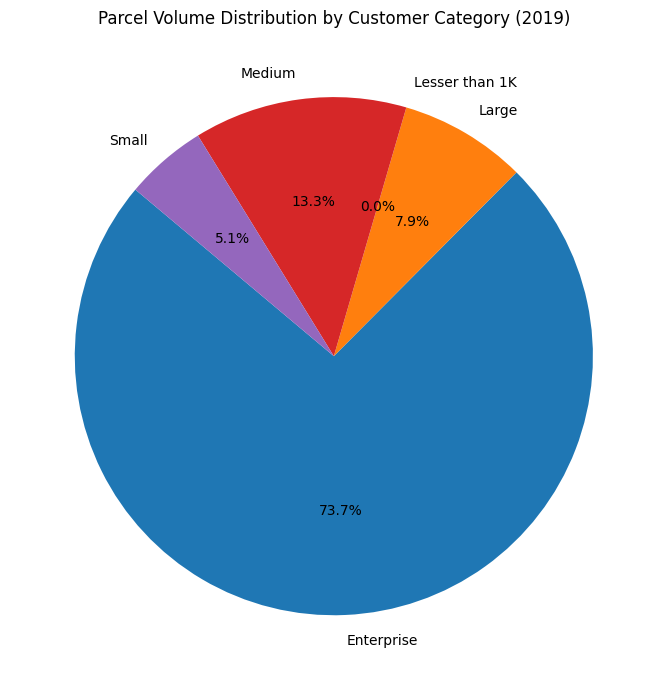

In [270]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.pie(
    pivot_category_year[2019],
    labels=pivot_category_year.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Parcel Volume Distribution by Customer Category (2019)')
plt.tight_layout()
plt.show()


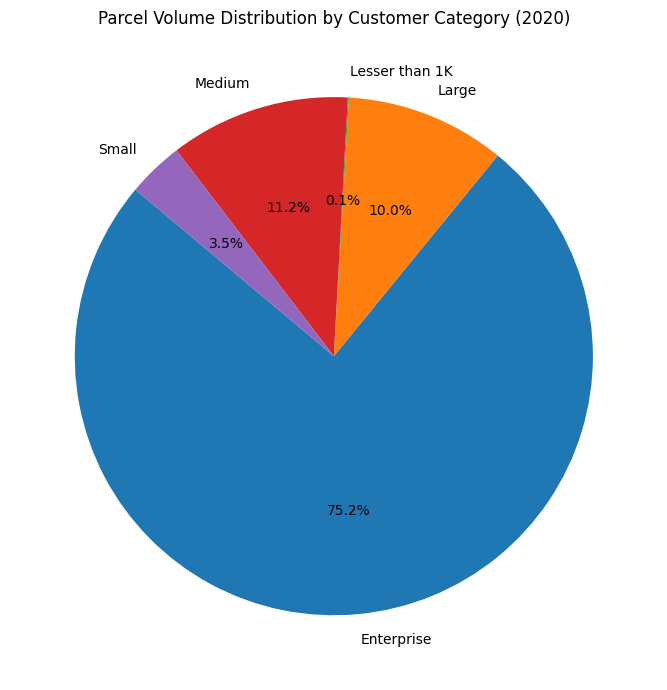

In [271]:
plt.figure(figsize=(7,7))
plt.pie(
    pivot_category_year[2020],
    labels=pivot_category_year.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Parcel Volume Distribution by Customer Category (2020)')
plt.tight_layout()
plt.show()


#### In 2020, Enterprise and Large customers accounted for a significantly higher share of total parcel volume compared to 2019, indicating that COVID accelerated volume concentration among high-volume customers. 

## What percent of each customer group is growing, moderately growing, and declining during the COVID observation period? 

### For this , we would have to use the covid observation period weeks for both 2020 and use the same for 2019 to compare.

In [235]:
pivot_category_year['GROWTH_%'] = (
    (pivot_category_year[2020] - pivot_category_year[2019]) / pivot_category_year[2019].replace(0, np.nan)
) * 100

pivot_category_year['GROWTH_%'] = pivot_category_year['GROWTH_%'].fillna(0)


In [236]:
def classify_growth(g):
    if g > 10:
        return 'Growing'
    elif 0 <= g <= 10:
        return 'Moderately Growing'
    else:
        return 'Declining'

pivot_category_year['GROWTH_CLASS'] = pivot_category_year['GROWTH_%'].apply(classify_growth)


In [237]:
print(pivot_category_year[['GROWTH_%', 'GROWTH_CLASS']])


THE_YEAR         GROWTH_%        GROWTH_CLASS
CATEGORY                                     
Enterprise      42.019863             Growing
Large           74.844243             Growing
Lesser than 1K   0.000000  Moderately Growing
Medium          17.608919             Growing
Small           -4.581017           Declining


In [276]:
color_map = {
    'Growing': 'tab:green',
    'Moderately Growing': 'tab:orange',
    'Declining': 'tab:red'
}

colors = pivot_category_year['GROWTH_CLASS'].map(color_map)


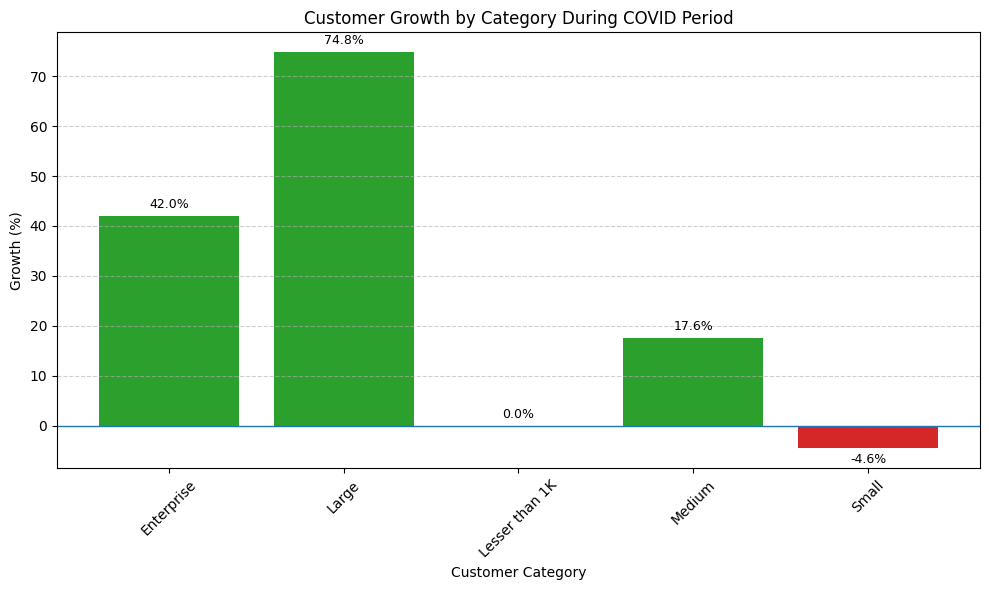

In [278]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(
    pivot_category_year.index,
    pivot_category_year['GROWTH_%'],
    color=colors
)

# Zero-growth reference line
plt.axhline(0, linewidth=1)

for bar in bars:
    height = bar.get_height()
    
    if height >= 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,                 # slightly above the bar
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )
    else:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height - 1,                 # slightly below the bar
            f'{height:.1f}%',
            ha='center',
            va='top',
            fontsize=9
        )

plt.xlabel('Customer Category')
plt.ylabel('Growth (%)')
plt.title('Customer Growth by Category During COVID Period')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Enterprise and Large customer groups experienced the strongest growth during the COVID period, while Small customers showed a contraction in volumes, indicating a shift toward higher-volume customers.

## •	What percent of each customer group are new customers during the COVID observation period? 

In [252]:
# Customers present in 2019
old_customers = set(customer_year_summary[customer_year_summary['THE_YEAR'] == 2019]['FakeCustomerID'])

df_2020 = customer_year_summary[customer_year_summary['THE_YEAR'] == 2020].copy()
df_2020['IS_NEW'] = ~df_2020['FakeCustomerID'].isin(old_customers)
new_customer_percent = df_2020.groupby('CATEGORY')['IS_NEW'].mean() * 100
print(new_customer_percent)


CATEGORY
Enterprise        0.0
Large             0.0
Lesser than 1K    0.0
Medium            0.0
Small             0.0
Name: IS_NEW, dtype: float64


### From the code above, we can see that for the covid periods, there were no news customers in  2020.

## •	What percent of 2019 customers in each group did we lose during the COVID observation period?

In [253]:
# Customers in 2019
customers_2019 = customer_year_summary[customer_year_summary['THE_YEAR'] == 2019][['FakeCustomerID', 'CATEGORY']]

# Customers in 2020
customers_2020 = customer_year_summary[customer_year_summary['THE_YEAR'] == 2020][['FakeCustomerID', 'CATEGORY']]

# Merge 2019 with 2020 to mark who is lost
merged = customers_2019.merge(
    customers_2020[['FakeCustomerID']],
    on='FakeCustomerID',
    how='left',
    indicator=True
)

# _merge column: 'left_only' = lost, 'both' = continued
merged['LOST'] = merged['_merge'] == 'left_only'


In [254]:
lost_percent = merged.groupby('CATEGORY')['LOST'].mean() * 100
print(lost_percent)


CATEGORY
Enterprise    0.000000
Large         0.000000
Medium        0.574713
Small         1.627907
Name: LOST, dtype: float64


### from the Pie Chart above we can say that 1.627% for customers in the Small category did not return in 2020, 0.57% of customers did not return in the Medium category. No customers were lost in the Entreprise and Large Category.

## •	What was the overall impact of COVID on volumes and revenue by customer group?
### we will be usign the formula :	ISGR(%)=(〖Volume〗_(current_period)-〖Volume〗_(previous_Period))/〖Volume〗_(previous_period) ×100

In [255]:
# Sum total volume per category per year
group_volumes = customer_year_summary.groupby(['CATEGORY', 'THE_YEAR'])['VOLUME'].sum().reset_index()

group_volumes

,CATEGORY,THE_YEAR,VOLUME
0,Enterprise,2019,38910324
1,Enterprise,2020,55260389
2,Large,2019,4191621
3,Large,2020,7328808
4,Lesser than 1K,2020,51238
5,Medium,2019,7027575
6,Medium,2020,8265055
7,Small,2019,2693594
8,Small,2020,2570200


### put the result in a pivot

In [257]:
pivot_group = group_volumes.pivot(index='CATEGORY', columns='THE_YEAR', values='VOLUME').fillna(0)
pivot_group = pivot_group.rename(columns={2019: 'VOL_2019', 2020: 'VOL_2020'})
pivot_group


THE_YEAR,VOL_2019,VOL_2020
CATEGORY,,
Enterprise,38910324.0,55260389.0
Large,4191621.0,7328808.0
Lesser than 1K,0.0,51238.0
Medium,7027575.0,8265055.0
Small,2693594.0,2570200.0


In [ ]:
pivot_group['ISGR_%'] = ((pivot_group['VOL_2020'] - pivot_group['VOL_2019']) / pivot_group['VOL_2019'].replace(0, np.nan)) * 100

In [259]:
BASE_COST = 22  # $ per parcel

# Revenue = Volume * base cost
pivot_group['REV_2019'] = pivot_group['VOL_2019'] * BASE_COST
pivot_group['REV_2020'] = pivot_group['VOL_2020'] * BASE_COST

# Revenue change
pivot_group['REV_CHANGE_$'] = pivot_group['REV_2020'] - pivot_group['REV_2019']
pivot_group['REV_CHANGE_%'] = ((pivot_group['REV_2020'] - pivot_group['REV_2019']) / pivot_group['REV_2019'].replace(0, np.nan)) * 100


In [260]:
pivot_group[['VOL_2019','VOL_2020','ISGR_%','REV_2019','REV_2020','REV_CHANGE_$','REV_CHANGE_%']]


THE_YEAR,VOL_2019,VOL_2020,ISGR_%,REV_2019,REV_2020,REV_CHANGE_$,REV_CHANGE_%
CATEGORY,,,,,,,
Enterprise,38910324.0,55260389.0,42.019863,856027128.0,1.215729e+09,359701430.0,42.019863
Large,4191621.0,7328808.0,74.844243,92215662.0,1.612338e+08,69018114.0,74.844243
Lesser than 1K,0.0,51238.0,NaN,0.0,1.127236e+06,1127236.0,NaN
Medium,7027575.0,8265055.0,17.608919,154606650.0,1.818312e+08,27224560.0,17.608919
Small,2693594.0,2570200.0,-4.581017,59259068.0,5.654440e+07,-2714668.0,-4.581017


### This table above shows the overall impact of COVID on both volumes and revenue per customer group.

In [261]:
categories = pivot_group.index
volumes_2019 = pivot_group['VOL_2019']
volumes_2020 = pivot_group['VOL_2020']
rev_2019 = pivot_group['REV_2019']
rev_2020 = pivot_group['REV_2020']


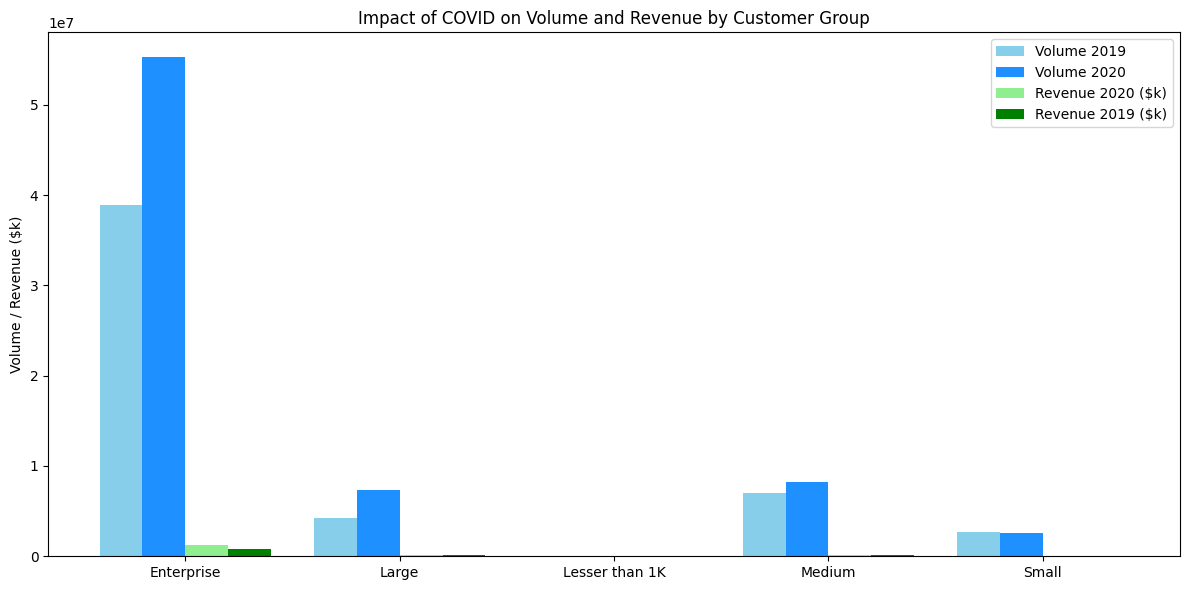

In [262]:
x = np.arange(len(categories))  # label locations
width = 0.2  # width of bars

plt.figure(figsize=(12,6))

# Volume bars
plt.bar(x - width, volumes_2019, width, label='Volume 2019', color='skyblue')
plt.bar(x, volumes_2020, width, label='Volume 2020', color='dodgerblue')

# Revenue bars (scaled down for visualization, e.g., divide by 1000 to match volume scale)
plt.bar(x + width, rev_2020/1000, width, label='Revenue 2020 ($k)', color='lightgreen')
plt.bar(x + 2*width, rev_2019/1000, width, label='Revenue 2019 ($k)', color='green')

# Labels
plt.xticks(x + width/2, categories)
plt.ylabel('Volume / Revenue ($k)')
plt.title('Impact of COVID on Volume and Revenue by Customer Group')
plt.legend()
plt.tight_layout()
plt.show()


### Reference: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
### :(https://colab.research.google.com/drive/15zc23I8e8EY0spIZZ5zD2d-Y6J0fECgW)
### : https://colab.research.google.com/drive/1CN69PzfD7-plzr4hpLJbJlNBsMp7rSqV